# Lecture 06

### Boot vs Jack


* **Boot**: works well for every statistics: mean, variance but also ranked based stats. Maps out the entire distribution since can be done N times with no restriction. It's computationally expensive and relies on random noise (thus not reproducable).

* **Jack**: doesn't work on ranked-based statistics. Doesn't map out the distribution of the estimator since it's limited by sample size. It's computationally cheaper and deterministic. It's built for bias correction of the estimator.

# Black-hole binary formation channels with gaussian mixtures.

### Introduction

Some events form in different astrophysical environments than others. You want to figure out how many of formation channels are at play.

The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of N gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$
 and weight $\alpha_j$:

 $$p(x_i|\theta) = \sum_{i=1}^N \alpha_j \mathcal{N}(\mu_j, \sigma_j)$$

This depends on $3N - 1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability, 1 constrain).

The dataset contains the masses of BH binaries.

### Tasks

- Load this file (np.load) and complete a quick exploration of the data. How many modes do you think you see?
- We'll use sklearn.mixture.GaussianMixture. You first need to define the model (instance of a class), and then train it on the data using the fit method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

- Complete the fit 10 times with $N = 1,...,10$ Gaussians.
  
$Note$: sklearn by default will use the so-called Expectation-Maximization algorithm, which is one of the many great things in data science we don't have time to study in this class.

- For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?
- Plot the preferred solution on top of the input data. You should get a very nice fit!

In [7]:
import numpy as np
from matplotlib import pyplot as plt

file_path = 'formationchannels.npy'
data = np.load(file_path)

N=3000
set_x = np.linspace(-10,50, N)

print(f"The \"shape\" of the data set is: {data.shape}")

The "shape" of the data set is: (2950, 1)


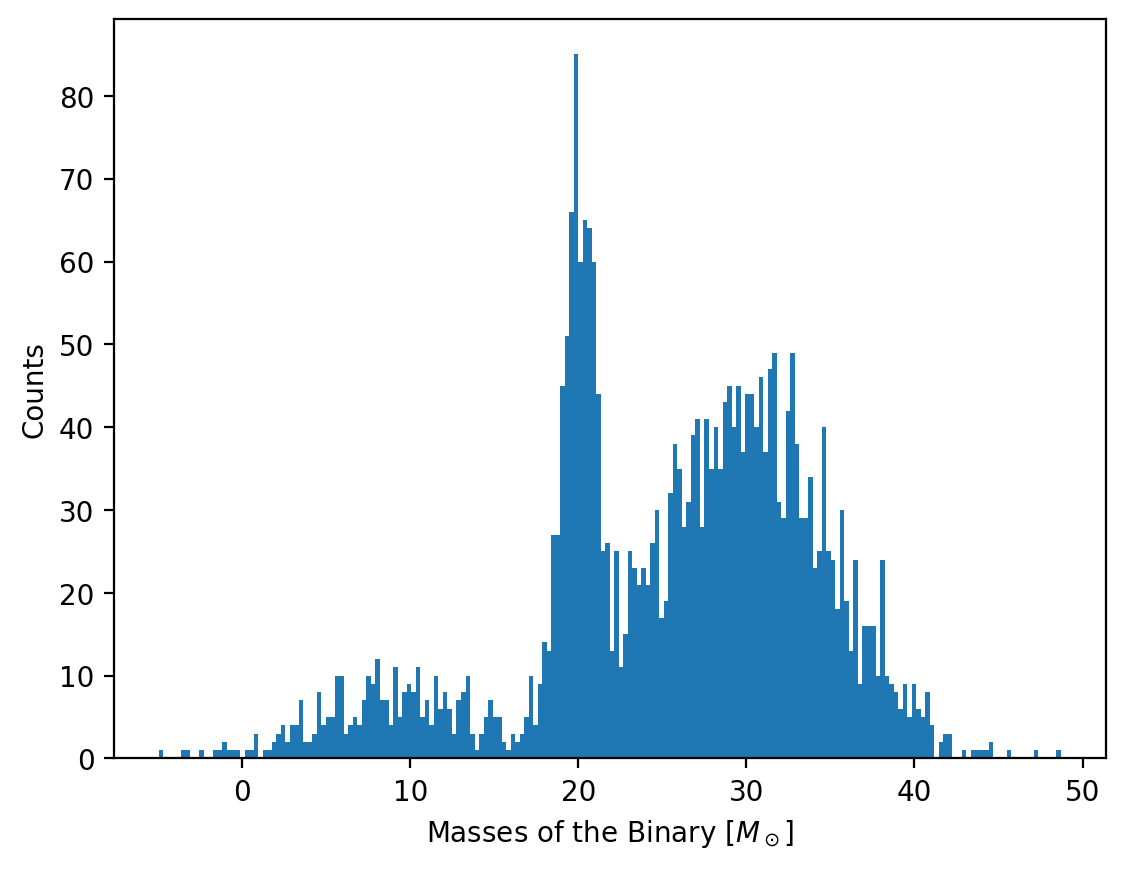

In [8]:
plt.hist(data, bins = 200)
plt.ylabel("Counts")
plt.xlabel(r"Masses of the Binary [$M_\odot$]")
plt.show()

### Gaussian Mixture

In [9]:
from sklearn.mixture import GaussianMixture as gm

def likelihood(x, mu, sigma):
    norm = 1/np.sqrt(2 * np.pi * sigma**2)
    exp = np.exp(-(x - mu)**2/(2*sigma**2))
    p = norm * exp
    return p

#### TEST 1
Try with 3 gaussians

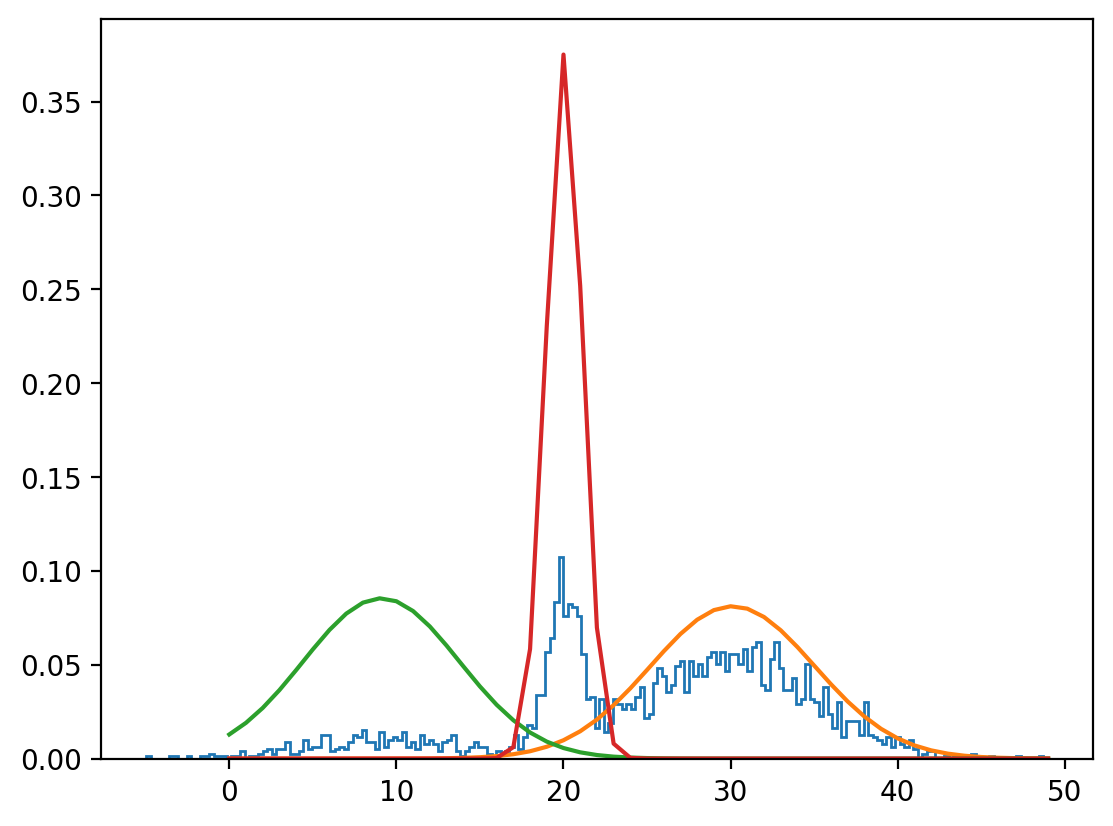

Parametri del Gaussian Mixture Model
Componente 1:
  Peso (w)    : 0.6698
  Media (mu)  : 30.1175
  Varianza    : 24.1637
  Dev. St. (s): 4.9157

Componente 2:
  Peso (w)    : 0.1163
  Media (mu)  : 9.0956
  Varianza    : 21.8276
  Dev. St. (s): 4.6720

Componente 3:
  Peso (w)    : 0.2139
  Media (mu)  : 20.0504
  Varianza    : 1.1289
  Dev. St. (s): 1.0625



In [15]:
gm1 = gm(n_components=3).fit(data)
set_x = np.arange(0,50)
gaussians = np.array([likelihood(set_x, mu_i, np.sqrt(sigma_i)) for mu_i, sigma_i in zip(gm1.means_.ravel(), gm1.covariances_.ravel())])

plt.hist(data, bins = 200, histtype = 'step', density = True)
plt.plot(set_x, gaussians.T)
plt.show()

pesi = gm1.weights_
medie = gm1.means_.ravel()
varianze = gm1.covariances_.ravel()

print("Parametri del Gaussian Mixture Model")
for i in range(gm1.n_components):
    print(f"Componente {i+1}:")
    print(f"  Peso (w)    : {pesi[i]:.4f}")
    print(f"  Media (mu)  : {medie[i]:.4f}")
    print(f"  Varianza    : {varianze[i]:.4f}")
    print(f"  Dev. St. (s): {np.sqrt(varianze[i]):.4f}\n")

#### TEST 2
try with different number of gaussians

In [17]:
n = range(1, 11)
gms = np.array([gm(int(i)).fit(data) for i in n])
many_gaus = []

print("Parametri dei Gaussian Mixture Models")

# Iteriamo su ogni modello GMM salvato nella tua lista 'gms'
for gmi in gms:
    n_comp = gmi.n_components
    print(f"MODELLO CON {n_comp} COMPONENTI")
    
    pesi = gmi.weights_
    medie = gmi.means_.ravel()
    varianze = gmi.covariances_.ravel()
    
    # 1. Stampa dei parametri
    for i in range(n_comp):
        print(f"  Componente {i+1}:")
        print(f"    Peso (w)    : {pesi[i]:.4f}")
        print(f"    Media (mu)  : {medie[i]:.4f}")
        print(f"    Varianza    : {varianze[i]:.4f}")
        print(f"    Dev. St. (s): {np.sqrt(varianze[i]):.4f}\n")
        
    # 2. Calcolo e salvataggio delle curve in many_gaus!
    plot = np.array([
        likelihood(set_x, mu_i, np.sqrt(sigma_i)) * w_i 
        for mu_i, sigma_i, w_i in zip(medie, varianze, pesi)
    ])
    many_gaus.append(plot)


Parametri dei Gaussian Mixture Models
MODELLO CON 1 COMPONENTI
  Componente 1:
    Peso (w)    : 1.0000
    Media (mu)  : 25.5201
    Varianza    : 70.8877
    Dev. St. (s): 8.4195

MODELLO CON 2 COMPONENTI
  Componente 1:
    Peso (w)    : 0.4473
    Media (mu)  : 19.8960
    Varianza    : 66.4654
    Dev. St. (s): 8.1526

  Componente 2:
    Peso (w)    : 0.5527
    Media (mu)  : 30.0714
    Varianza    : 28.1547
    Dev. St. (s): 5.3061

MODELLO CON 3 COMPONENTI
  Componente 1:
    Peso (w)    : 0.3639
    Media (mu)  : 25.0961
    Varianza    : 23.7711
    Dev. St. (s): 4.8756

  Componente 2:
    Peso (w)    : 0.3491
    Media (mu)  : 19.7318
    Varianza    : 86.6158
    Dev. St. (s): 9.3068

  Componente 3:
    Peso (w)    : 0.2870
    Media (mu)  : 33.0989
    Varianza    : 13.0872
    Dev. St. (s): 3.6176

MODELLO CON 4 COMPONENTI
  Componente 1:
    Peso (w)    : 0.2340
    Media (mu)  : 20.0924
    Varianza    : 1.3137
    Dev. St. (s): 1.1462

  Componente 2:
    Peso (w)  

Valori nella lista n: range(1, 11)
Modelli salvati in many_gaus: 10


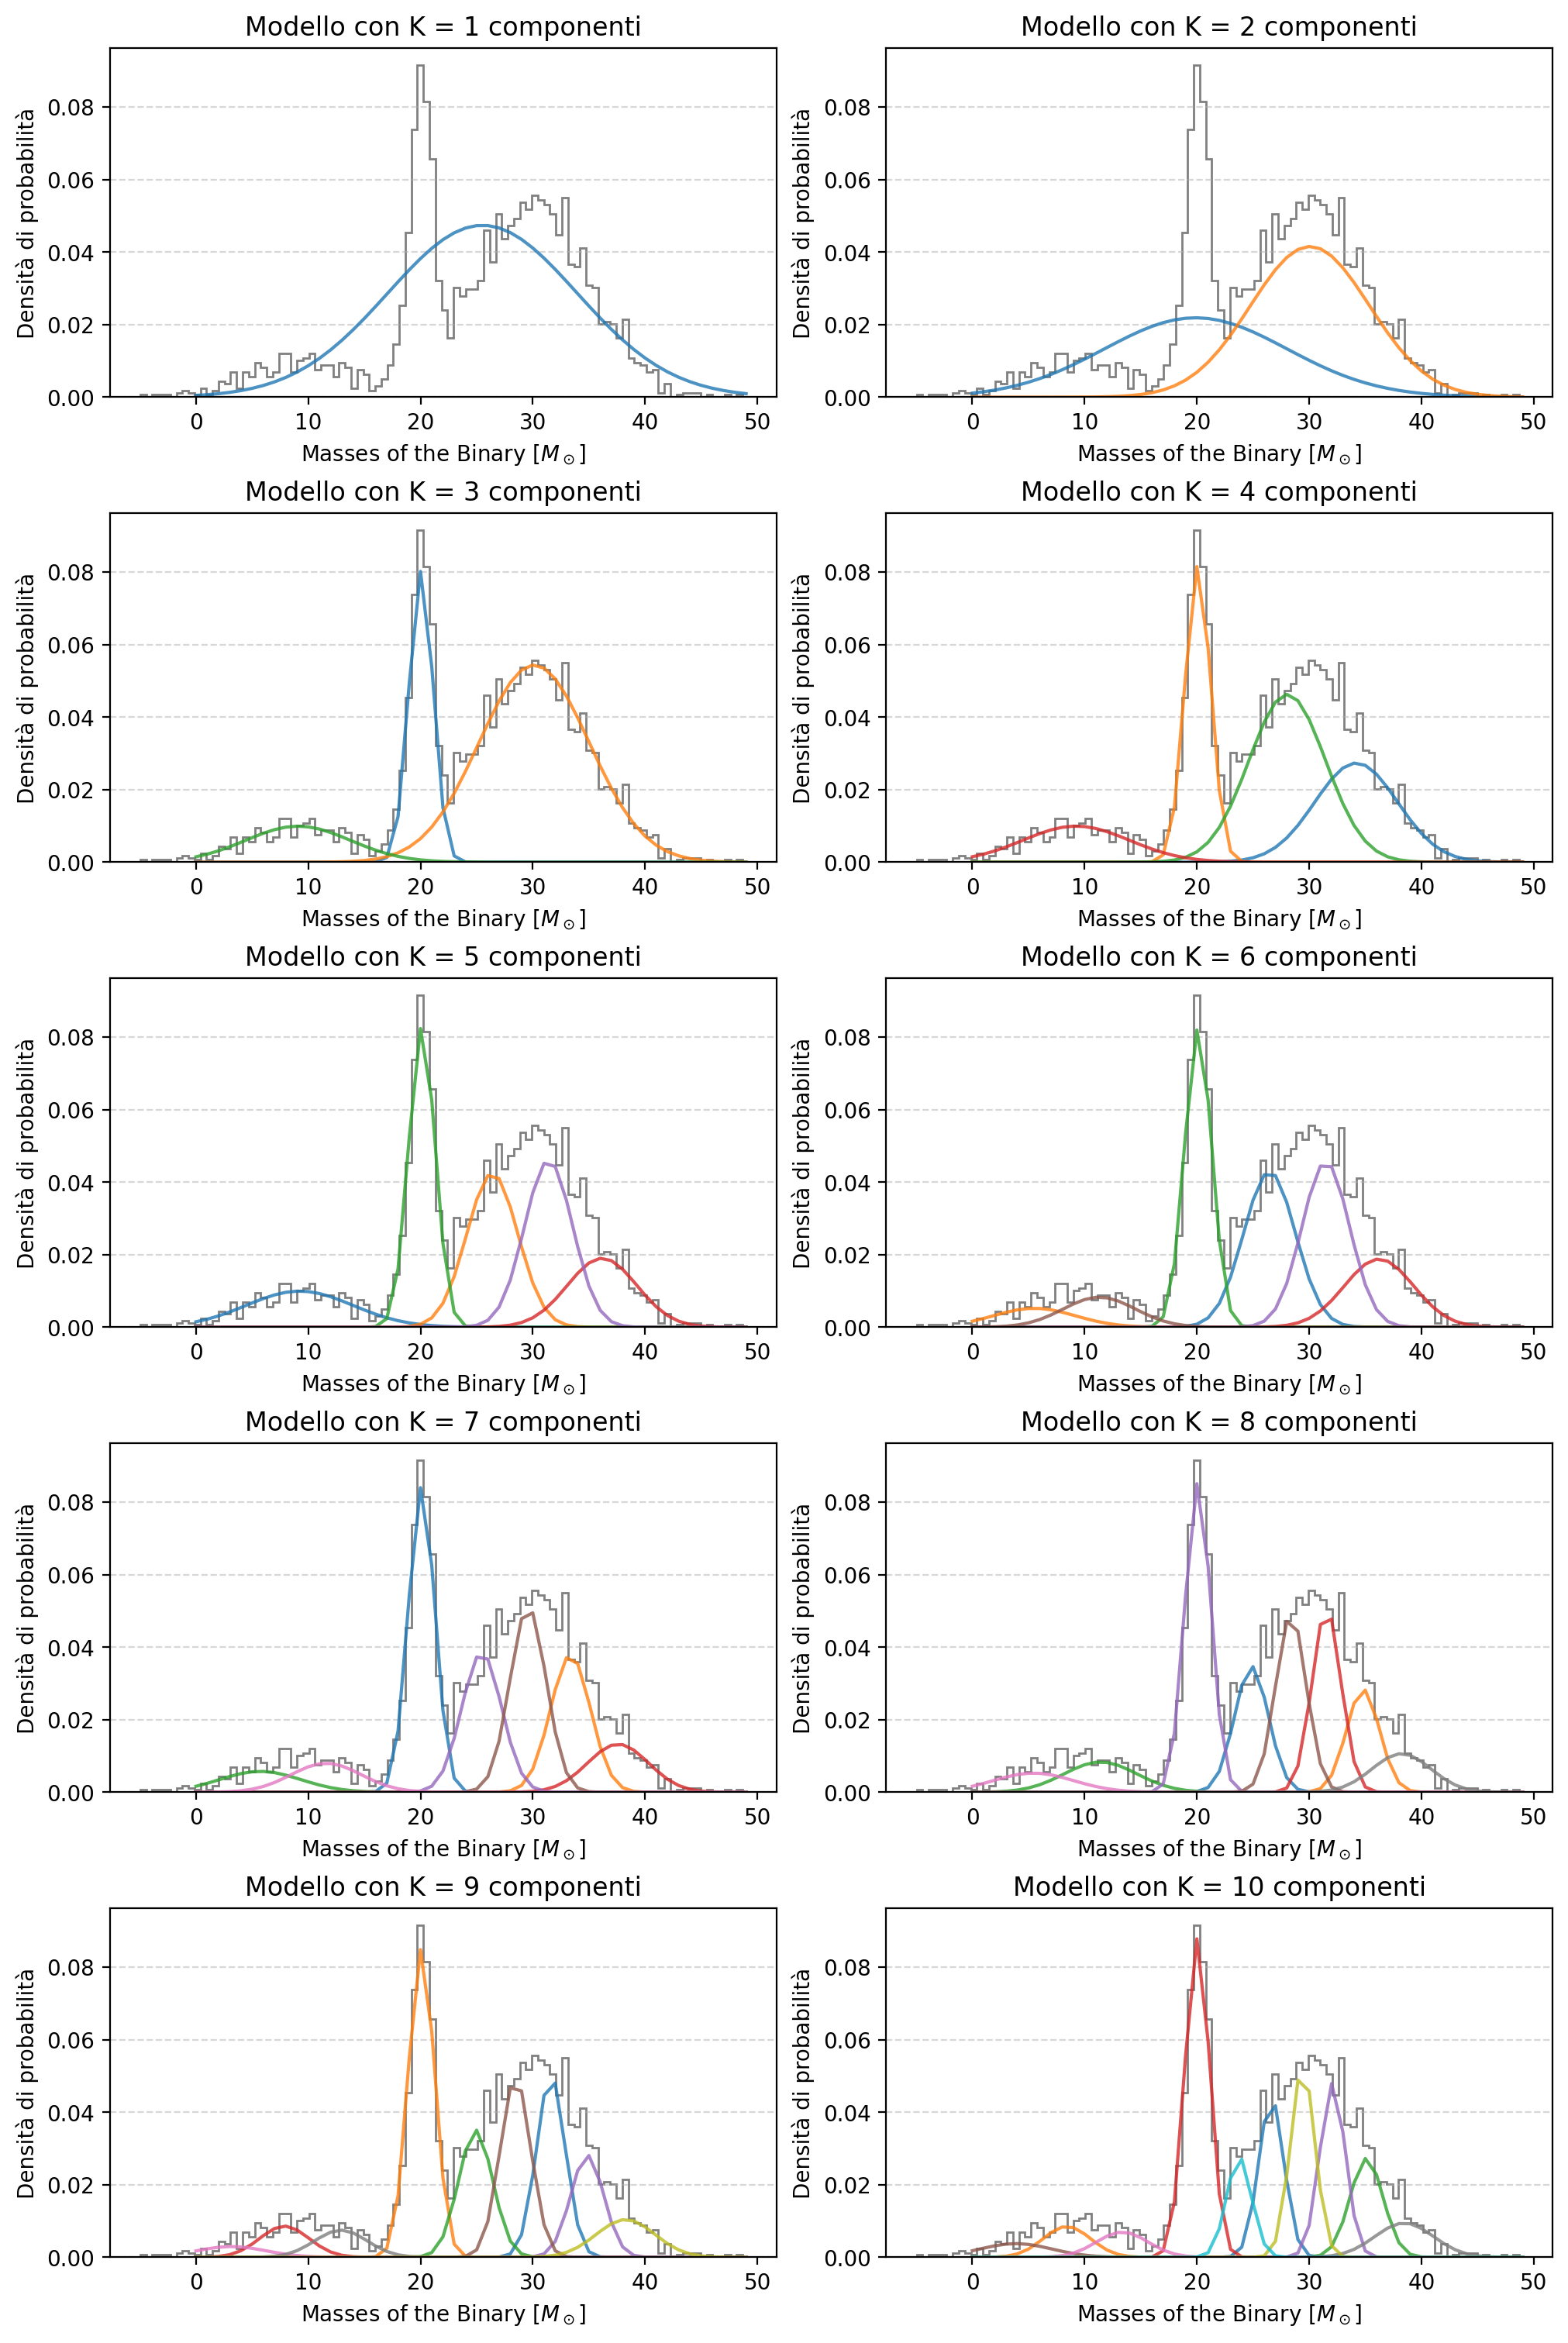

In [12]:
print(f"Valori nella lista n: {n}")
print(f"Modelli salvati in many_gaus: {len(many_gaus)}")
fig, axes = plt.subplots(5, 2, figsize=(10, 15), constrained_layout=True)
axes = axes.flatten() # Trasformiamo la matrice di assi in una lista piatta

for i, ax in enumerate(axes):
    # Controllo di sicurezza: se abbiamo esaurito i modelli, nascondiamo l'asse vuoto
    if i >= len(many_gaus):
        ax.set_visible(False)
        continue
        
    gaus_model = many_gaus[i]
    
    # 1. Plot istogramma sui dati (sullo sfondo)
    ax.hist(data, bins=100, histtype='step', density=True, color='gray', label='Dati', zorder=1)
    
    # 2. Plot delle singole gaussiane
    # Usiamo alpha per renderle leggermente trasparenti e non coprire l'istogramma
    ax.plot(set_x, gaus_model.T, alpha=0.8, zorder=2)
    
    # Il titolo prende il numero di componenti dalla lista n
    ax.set_title(f"Modello con K = {n[i]} componenti")
    ax.set_xlabel(r"Masses of the Binary [$M_\odot$]")
    ax.set_ylabel("Densità di probabilità")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Akaike Information Criterion (AIC)

The **AIC** is an estimator of relative quality of statistical models for a given set of data. It is based on the principle of parsimony: it seeks the best compromise between the goodness-of-fit and the simplicity of the model, introducing a penalty term to avoid **overfitting**.

The mathematical definition is:

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

Where:
* $k$: is the number of estimated parameters in the model (representing the penalty for complexity).
* $\hat{L}$: is the maximum value of the likelihood function for the model.

**Decision Rule:** Given a set of candidate models, the preferred model is the one with the **minimum AIC value**. The $-2\ln(\hat{L})$ term rewards models that fit the data well, while the $2k$ term penalizes unnecessarily complex models.

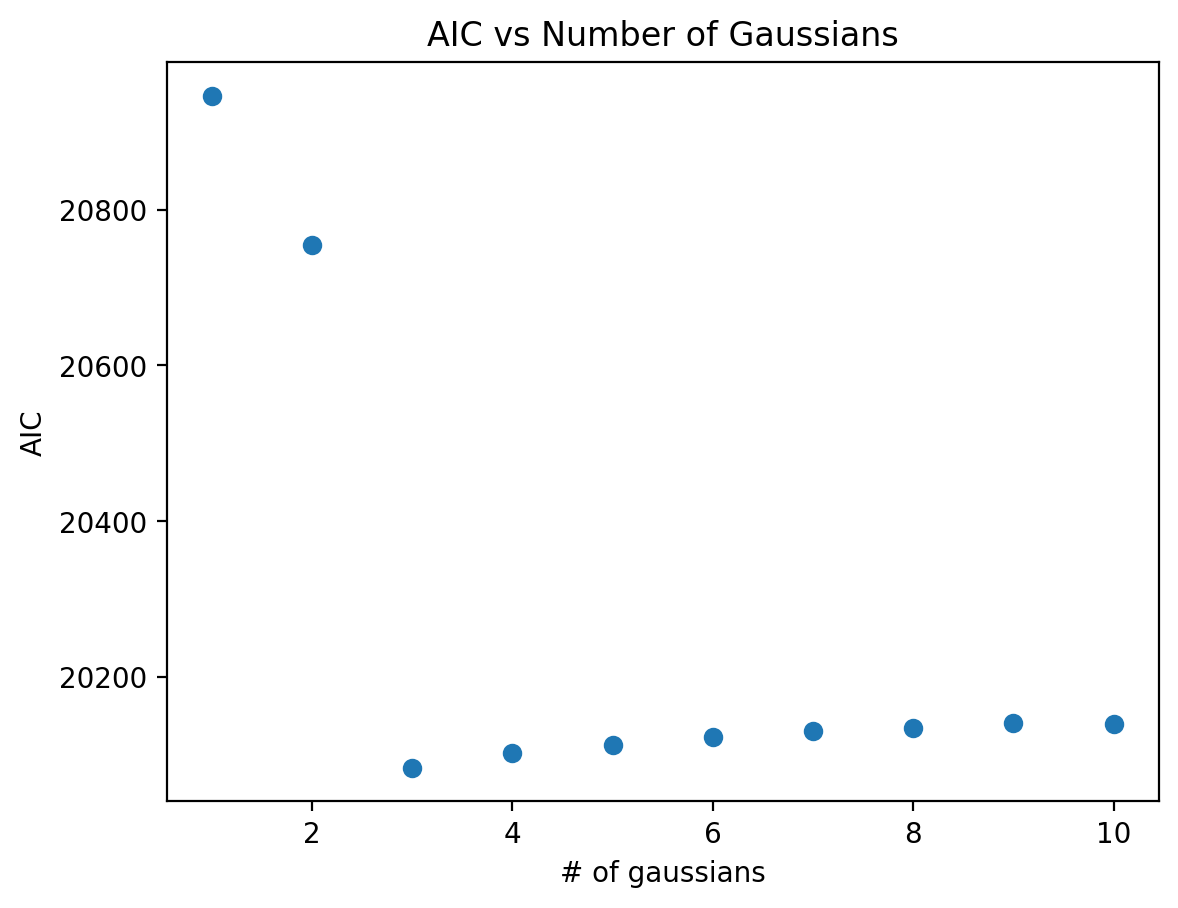

In [13]:
aics = np.array([gmi.aic(data) for gmi in gms])

plt.scatter(n, aics)
plt.title("AIC vs Number of Gaussians")
plt.ylabel("AIC")
plt.xlabel("# of gaussians")
plt.show()